In [1]:
# ------------------------------------------------------------------
# Setup  ▸  run once per notebook / session
# ------------------------------------------------------------------
# !pip install earthengine-api geemap

import ee, geemap, json, numpy as np
import matplotlib.pyplot as plt
from typing import Union, Tuple, Dict

# Authenticate if needed
try:
    ee.Initialize()
except Exception:
    ee.Authenticate()      # first run → browser OAuth
    ee.Initialize()

In [2]:
# ------------------------------------------------------------------
# Helper ▸ fetch_dem_with_fringe
# ------------------------------------------------------------------
def fetch_dem_with_fringe(
    geojson: Union[str, Dict],
    dem_id: str      = "USGS/SRTMGL1_003",
    scale: float     = 30,          # metres per pixel (SRTM native)
    fringe_m: float  = 0            # grow (+) or shrink (−) AOI in metres
) -> Tuple[np.ndarray, ee.Image, Dict]:
    """
    Parameters
    ----------
    geojson   : dict | str   – Polygon or MultiPolygon (WGS84)
    dem_id    : str          – GEE asset ID of the DEM
    scale     : float        – sampling resolution in metres
    fringe_m  : float        – buffer distance applied to AOI (metres)

    Returns
    -------
    arr       : np.ndarray   – 2-D masked array of elevation values
    img       : ee.Image     – clipped DEM (still geographic)
    bbox      : dict         – bounding box (lon/lat) of the sampled raster
                               {xmin, xmax, ymin, ymax}
    """

    # Accept either a dict or a JSON string
    if isinstance(geojson, str):
        geojson = json.loads(geojson)

    geom = ee.Geometry(geojson)

    # Grow (or shrink) the region if requested
    if fringe_m != 0:
        geom = geom.buffer(fringe_m)

    # Clip DEM to geometry, keep WGS84 CRS
    img = ee.Image(dem_id).select("elevation").clip(geom)

    # Region to sample = bounding box of (buffered) geometry
    region = geom.bounds()

    # Download pixels as NumPy array  (shape: rows × cols × 1)
    arr = geemap.ee_to_numpy(img, region=region, scale=scale)
    arr = np.squeeze(arr)  # drop the singleton band dimension

    # Bounding box for quick plotting
    coords = region.getInfo()["coordinates"][0]
    xs, ys = zip(*coords)
    bbox = dict(xmin=min(xs), xmax=max(xs), ymin=min(ys), ymax=max(ys))

    return arr, img, bbox

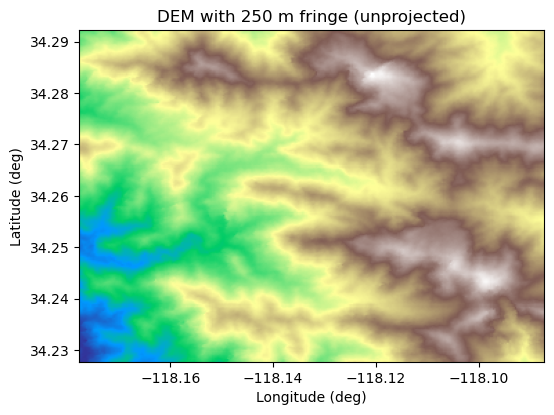

In [3]:
# ------------------------------------------------------------------
# Example ▸ test with a pentagon + 250 m fringe
# ------------------------------------------------------------------
pentagon_geojson = {
    "type": "Polygon",
    "coordinates": [[
        [-118.175, 34.28],   # roughly in the San Gabriel Mountains
        [-118.140, 34.26],
        [-118.120, 34.23],
        [-118.090, 34.26],
        [-118.110, 34.29],
        [-118.175, 34.28]    # close ring
    ]]
}

dem_np, dem_img, bb = fetch_dem_with_fringe(
    pentagon_geojson,
    scale=30,
    fringe_m=250     # add 250 m buffer all around
)

# ------------------------------------------------------------------
# Quick-look plot (optional)
# ------------------------------------------------------------------
plt.figure(figsize=(6, 6))
plt.imshow(
    np.ma.masked_invalid(dem_np),
    cmap="terrain",
    extent=[bb["xmin"], bb["xmax"], bb["ymin"], bb["ymax"]],
    origin="upper",
)
plt.title("DEM with 250 m fringe (unprojected)")
plt.xlabel("Longitude (deg)")
plt.ylabel("Latitude (deg)")
plt.show()

In [4]:
# ------------------------------------------------------------------
# 0.  One-time installs (if you don’t have these already)
# ------------------------------------------------------------------
# !pip install trimesh shapely k3d

import numpy as np
import trimesh, k3d, json, math
from pathlib import Path
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# 1.  DEM ➜ triangular surface ➜ STL
# ------------------------------------------------------------------
def dem_to_surface_stl(
    dem_np: np.ndarray,
    bbox: dict,
    out_stl: str | Path = "dem_surface.stl",
    vertical_exaggeration: float = 1.0,
    show_k3d: bool = True,
):
    """
    Parameters
    ----------
    dem_np      : 2-D NumPy array (np.nan outside AOI)
    bbox        : {'xmin', 'xmax', 'ymin', 'ymax'}   in degrees
    out_stl     : filename to write the STL
    v_exag      : vertical exaggeration factor (1 = true scale)
    show_k3d    : whether to render the mesh in the notebook

    Returns
    -------
    mesh        : trimesh.Trimesh   – the surface mesh
    """

    rows, cols = dem_np.shape

    # --- 1a.  Build vertex grid (cell centres) ---------------------------
    lon_step = (bbox["xmax"] - bbox["xmin"]) / cols
    lat_step = (bbox["ymax"] - bbox["ymin"]) / rows

    # Centre coordinates for each cell
    lon = bbox["xmin"] + (np.arange(cols) + 0.5) * lon_step
    lat = bbox["ymax"] - (np.arange(rows) + 0.5) * lat_step
    lon_grid, lat_grid = np.meshgrid(lon, lat)

    z = dem_np * vertical_exaggeration          # apply exaggeration
    mask = ~np.isnan(z)                         # True where data exist

    # Flatten to 1-D
    verts = np.column_stack(
        (lon_grid.ravel(), lat_grid.ravel(), z.ravel())
    ).astype(np.float32)

    # --- 1b.  Build faces  (two tris per quad) ---------------------------
    faces = []
    for r in range(rows - 1):
        for c in range(cols - 1):
            # Indices of the four corners of the current cell
            i00 = r * cols + c
            i10 = i00 + 1
            i01 = i00 + cols
            i11 = i01 + 1

            # Only create faces if all four cells have data
            if mask.ravel()[[i00, i10, i01, i11]].all():
                # Lower left tri  (i00, i01, i11)
                faces.append([i00, i01, i11])
                # Upper right tri (i00, i11, i10)
                faces.append([i00, i11, i10])

    faces = np.array(faces, dtype=np.uint32)

    # --- 2.  Create trimesh & save ---------------------------------------
    mesh = trimesh.Trimesh(vertices=verts, faces=faces, process=False)
    mesh.export(out_stl)
    print(f"✓ STL written to {Path(out_stl).resolve()}  "
          f"({len(mesh.vertices):,d} verts, {len(mesh.faces):,d} faces)")

    # --- 3.  Optional 3-D preview ---------------------------------------
    if show_k3d:
        plot = k3d.plot()
        plot += k3d.mesh(
            vertices=mesh.vertices.astype(np.float32),
            indices=mesh.faces.astype(np.uint32),
            wireframe=False,
            color=0xE0E0E0,
            flat_shading=False,
        )
        plot.display()

    return mesh

# ------------------------------------------------------------------
# 2.  Example: build & view surface for the pentagon AOI
# ------------------------------------------------------------------
# Assume you just ran fetch_dem_with_fringe(...) and have:
#   • dem_np   – 2-D array
#   • bb       – bounding box dict
# If not, re-run the earlier cell first.

mesh = dem_to_surface_stl(
    dem_np,
    bbox=bb,
    out_stl="pentagon_dem_surface.stl",
    vertical_exaggeration=1.2,   # optional exaggeration
    show_k3d=True                # interactive preview 🎉
)


✓ STL written to /TouchTerrain/standalone/pentagon_dem_surface.stl  (80,976 verts, 160,800 faces)


/opt/conda/lib/python3.10/site-packages/traittypes/traittypes.py:97: UserWarning: Given trait value dtype "float32" does not match required type "float32". A coerced copy has been created.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/traittypes/traittypes.py:97: UserWarning: Given trait value dtype "uint32" does not match required type "uint32". A coerced copy has been created.
  warnings.warn(


Output()

In [38]:
# ------------------------------------------------------------
# 0 ▸ basic imports (run once per notebook)
# ------------------------------------------------------------
# !pip install shapely trimesh k3d
import numpy as np, trimesh, k3d
from shapely.geometry import shape
from pathlib import Path
from pyproj import Transformer, CRS

# ------------------------------------------------------------
# 1 ▸ helper – make a rectangular DEM block
# ------------------------------------------------------------
def dem_sheet_to_block(
    surf_mesh: trimesh.Trimesh,
    rows: int,
    cols: int,
    base_value: float = 50.0,       # offset or absolute Z, depending on base_mode
    base_mode: str = "offset"       # "offset" (default) or "absolute"
) -> trimesh.Trimesh:
    """
    Convert a regular-grid DEM surface into a watertight solid.

    Parameters
    ----------
    surf_mesh   : trimesh.Trimesh   – open surface from dem_to_surface_stl
    rows, cols  : int               – original DEM grid shape
    base_value  : float             – offset from bottom (if mode='offset'),
                                      or absolute Z value (if mode='absolute')
    base_mode   : str               – 'offset' or 'absolute'
    """

    top_v = surf_mesh.vertices
    z_min = top_v[:, 2].min()

    if base_mode == "offset":
        z_base = z_min - abs(base_value)
    elif base_mode == "absolute":
        z_base = float(base_value)
    else:
        raise ValueError(f"Invalid base_mode: {base_mode}. Use 'offset' or 'absolute'.")

    bot_v = top_v.copy()
    bot_v[:, 2] = z_base

    verts = np.vstack([top_v, bot_v])
    n_top = rows * cols

    faces = surf_mesh.faces.tolist()

    # ---- 1a ▸ vertical wall faces
    def wall_strip(idx_top, idx_next):
        faces.append([idx_top, idx_next, idx_next + n_top])
        faces.append([idx_top, idx_next + n_top, idx_top + n_top])

    # top edge
    for c in range(cols - 1):
        wall_strip(c, c + 1)
    # right edge
    for r in range(rows - 1):
        wall_strip(r * cols + cols - 1, (r + 1) * cols + cols - 1)
    # bottom edge
    offset = (rows - 1) * cols
    for c in range(cols - 1, 0, -1):
        wall_strip(offset + c, offset + c - 1)
    # left edge
    for r in range(rows - 1, 0, -1):
        wall_strip(r * cols, (r - 1) * cols)

    # ---- 1b ▸ bottom cap
    for r in range(rows - 1):
        for c in range(cols - 1):
            i00 = r * cols + c
            i10 = i00 + 1
            i01 = i00 + cols
            i11 = i01 + 1
            # bottom triangles
            faces.append([i00 + n_top, i11 + n_top, i10 + n_top])
            faces.append([i00 + n_top, i01 + n_top, i11 + n_top])

    block = trimesh.Trimesh(vertices=verts, faces=np.array(faces), process=False)
    block.remove_duplicate_faces()
    block.merge_vertices()
    block.fix_normals()

    return block


# ------------------------------------------------------------
# 2 ▸ helper – boolean clip with AOI prism
# ------------------------------------------------------------
from shapely.geometry import shape, Polygon
from pyproj import Transformer
import numpy as np
import trimesh, k3d
from pathlib import Path

def clip_dem_block(
    dem_block: trimesh.Trimesh,
    aoi_geojson: dict,
    out_stl: str | Path = "dem_clipped.stl",
    prism_stl: str | Path = "aoi_prism.stl",
    z_padding: float = 20.0,
    project_crs: str | None = "auto",    # e.g. "EPSG:32611" or "auto"
    xy_scale: float = 1.0,               # scale horizontal size
    z_scale: float = 1.0,                # scale height exaggeration
    show_k3d: bool = True,
):
    """
    Projects DEM and AOI into a planar CRS, optionally scales, performs boolean intersection.
    """

    # -- 1. Select projection CRS
    def auto_utm(lon, lat):
        zone = int((lon + 180) / 6) + 1
        epsg = 32600 + zone if lat >= 0 else 32700 + zone
        return f"EPSG:{epsg}"

    centroid = shape(aoi_geojson).centroid
    crs_out = auto_utm(centroid.x, centroid.y) if project_crs == "auto" else project_crs
    transformer = Transformer.from_crs("EPSG:4326", crs_out, always_xy=True)

    # -- 2. Project DEM block
    dem_v = dem_block.vertices.copy()
    x_proj, y_proj = transformer.transform(dem_v[:, 0], dem_v[:, 1])
    dem_v[:, 0] = x_proj * xy_scale
    dem_v[:, 1] = y_proj * xy_scale
    dem_v[:, 2] *= z_scale
    dem_block_proj = trimesh.Trimesh(vertices=dem_v, faces=dem_block.faces, process=False)

    # -- 3. Project and extrude AOI
    geom = shape(aoi_geojson)
    z0, z1 = dem_block_proj.bounds[0][2], dem_block_proj.bounds[1][2]

    geoms = [geom] if geom.geom_type == "Polygon" else list(geom.geoms)
    prisms = []
    for g in geoms:
        xy_proj = [transformer.transform(*pt) for pt in g.exterior.coords]
        scaled_xy = [(x * xy_scale, y * xy_scale) for x, y in xy_proj]
        poly = Polygon(scaled_xy)
        prism = trimesh.creation.extrude_polygon(
            polygon=poly,
            height=(z1 - z0) + 2 * z_padding,
            transform=trimesh.transformations.translation_matrix([0, 0, z0 - z_padding]),
        )
        prisms.append(prism)

    aoi_prism = trimesh.util.concatenate(prisms) if len(prisms) > 1 else prisms[0]

    # -- 4. Export the AOI prism
    aoi_prism.export(prism_stl)
    print(f"✓ AOI prism STL saved: {Path(prism_stl).resolve()}")

    # -- 5. Boolean intersection (NO engine explicitly specified!)
    print("⧗ Boolean intersection (default engine) …")
    clipped = dem_block_proj.intersection(aoi_prism, check_volume=True)

    if clipped.is_empty:
        raise RuntimeError("Boolean result is empty – check geometry or scaling.")

    # -- 6. Export final result
    clipped.export(out_stl)
    print(f"✓ Clipped STL saved: {Path(out_stl).resolve()}")

    # -- 7. Preview (optional)
    if show_k3d:
        plot = k3d.plot()
        plot += k3d.mesh(
            vertices=clipped.vertices.astype(np.float32),
            indices=clipped.faces.astype(np.uint32),
            color=0xCCCCCC,
            flat_shading=False,
        )
        plot.display()

    return clipped



In [41]:
# ------------------------------------------------------------
# 3 ▸ example pipeline
# ------------------------------------------------------------
# dem_np, bb         = fetch_dem_with_fringe(...)  # from earlier
# dem_surf_mesh      = dem_to_surface_stl(...)     # step before
# pentagon_geojson   = AOI polygon

rows, cols = dem_np.shape
block = dem_sheet_to_block(mesh, rows, cols, base_value=5.0)

out_path = Path("watertight_dem_block.stl")
dem_block.export(out_path)
print(f"✓ Saved: {out_path}")

clipped_mesh = clip_dem_block(
    dem_block     = dem_block,
    aoi_geojson   = pentagon_geojson,
    out_stl       = "dem_clipped.stl",
    prism_stl     = "aoi_prism.stl",
    project_crs   = "auto",           # or "EPSG:32611"
    xy_scale      = 1/1000,           # scale to millimeters
    z_scale       = 2/1000,           # height exaggeration in mm
    show_k3d      = True
)

/tmp/ipykernel_36204/1816058813.py:81: DeprecationWarning: `remove_duplicate_faces` is deprecated and will be removed in March 2024: replace with `mesh.update_faces(mesh.unique_faces())`
  block.remove_duplicate_faces()


✓ Saved: watertight_dem_block.stl
✓ AOI prism STL saved: /TouchTerrain/standalone/aoi_prism.stl
⧗ Boolean intersection (default engine) …
✓ Clipped STL saved: /TouchTerrain/standalone/dem_clipped.stl


Output()